In [1]:
# PIP installs
!pip install numpy torch matplotlib pandas datasets transformers trl

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# conda installs
# %conda install -c conda-forge -c pytorch numpy pytorch matplotlib pandas datasets transformers trl

In [3]:
# %conda list numpy

In [2]:
!pip show numpy

Name: numpy
Version: 2.4.3
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: 
Location: /home/dheerajb_iitp/.local/lib/python3.12/site-packages
Requires: 
Required-by: accelerate, contourpy, datasets, matplotlib, pandas, transformers


In [3]:
!pip install latex2sympy2-extended pylatexenc sympy

Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install math-verify

Defaulting to user installation because normal site-packages is not writeable


In [5]:
!pip show math-verify

Name: math-verify
Version: 0.9.0
Summary: HuggingFace library for verifying mathematical answers
Home-page: 
Author: 
Author-email: Hynek Kydlíček <hynek.kydlicek@huggingface.co>
License: Apache 2.0
Location: /home/dheerajb_iitp/.local/lib/python3.12/site-packages
Requires: latex2sympy2_extended
Required-by: 


In [6]:
!pip show torch

Name: torch
Version: 2.10.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /home/dheerajb_iitp/.local/lib/python3.12/site-packages
Requires: cuda-bindings, filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate


In [1]:
import torch

In [2]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("__Number CUDA Devices:", torch.cuda.device_count())
    print("__CUDA Device Name:", torch.cuda.get_device_name(0))
    print("__CUDA Version:", torch.version.cuda)


PyTorch version: 2.10.0+cu128
CUDA available: True
__Number CUDA Devices: 2
__CUDA Device Name: NVIDIA A100 80GB PCIe
__CUDA Version: 12.8


In [3]:
import json
import math
import sys
import time
import traceback
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Optional
import pyarrow as pa
import pyarrow.parquet as pq

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainerCallback
from trl import GRPOConfig, GRPOTrainer

sys.path.insert(0, ".")
from math_grader import extract_answer, grade, compute_score
from math_grader.cluster import TTRLClusterCounter

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CONVERT JSON → PARQUET  (run once, reuse forever)
# ─────────────────────────────────────────────────────────────────────────────

def convert_json_to_parquet(
    json_path: str,
    parquet_path: str,
    tokenizer_name: str = "Qwen/Qwen2.5-Math-1.5B",
    max_prompt_length: int = 512,
):
    """
    Converts your JSON dataset to Parquet with:
      - Structured chat prompt column
      - Pre-tokenized input_ids (saves re-tokenizing every epoch)
      - Compression (snappy — fast decompress, good ratio)
    """
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    with open(json_path, "r") as f:
        raw = json.load(f)

    records = []
    for item in raw:
        # ── Build chat messages ───────────────────────────────────────────────
        messages = [
            {
                "role": "system",
                "content": (
                    "You are a helpful math assistant. "
                    "Solve the problem step by step and put your "
                    "final answer inside \\boxed{}."
                ),
            },
            {
                "role": "user",
                "content": item["prompt"],
            },
        ]

        # ── Pre-tokenize prompt ───────────────────────────────────────────────
        prompt_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
        tokenized = tokenizer(
            prompt_text,
            truncation=True,
            max_length=max_prompt_length,
            padding=False,
        )

        records.append({
            # Raw fields
            "id":     item.get("id", ""),
            "source": item.get("source", ""),
            "answer": item.get("answer", ""),

            # Structured prompt (what GRPOTrainer expects)
            "prompt": messages,

            # Pre-tokenized — avoids re-tokenizing every epoch
            "input_ids":      tokenized["input_ids"],
            "attention_mask": tokenized["attention_mask"],
            "prompt_length":  len(tokenized["input_ids"]),
        })

    # ── Write Parquet with snappy compression ─────────────────────────────────
    df    = pd.DataFrame(records)
    table = pa.Table.from_pandas(df)
    pq.write_table(
        table,
        parquet_path,
        compression="snappy",       # fast decompress, ~3x smaller than JSON
        row_group_size=100,         # tune: smaller = faster random access
    )

    print(f"✅ Saved {len(records)} records → {parquet_path}")
    print(f"   JSON size:    {_file_size(json_path)}")
    print(f"   Parquet size: {_file_size(parquet_path)}")
    print(f"   Avg prompt length: {df['prompt_length'].mean():.0f} tokens")
    return parquet_path


def _file_size(path):
    import os
    size = os.path.getsize(path)
    for unit in ["B", "KB", "MB", "GB"]:
        if size < 1024:
            return f"{size:.1f} {unit}"
        size /= 1024


In [5]:
# # ── Run conversion once ───────────────────────────────────────────────────────
# convert_json_to_parquet(
#     json_path      = "your_data.json",
#     parquet_path   = "ttrl_data.parquet",
#     tokenizer_name = "Qwen/Qwen2.5-Math-1.5B",
# )

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. DATASET LOADING
# ─────────────────────────────────────────────────────────────────────────────

def load_dataset_from_parquet(parquet_path: str) -> Dataset:
    dataset = Dataset.from_parquet(parquet_path)
    print(f"✅ Loaded {len(dataset)} problems | Columns: {dataset.column_names}")
    return dataset


def load_dataset_from_json(json_path: str) -> Dataset:
    with open(json_path, "r") as f:
        raw = json.load(f)
    records = []
    for item in raw:
        records.append({
            "prompt": [
                {
                    "role": "system",
                    "content": (
                        "You are a helpful math assistant. "
                        "Solve the problem step by step and put your "
                        "final answer inside \\boxed{}."
                    ),
                },
                {"role": "user", "content": item["prompt"]},
            ],
            "answer": item.get("answer", ""),
            "source": item.get("source", ""),
            "id":     item.get("id", ""),
        })
    return Dataset.from_list(records)


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def flatten_completion(c) -> str:
    if isinstance(c, str):
        return c
    if isinstance(c, list):
        for msg in reversed(c):
            if isinstance(msg, dict) and "content" in msg:
                return str(msg["content"])
        return str(c)
    if isinstance(c, dict):
        return str(c.get("content", c))
    return str(c)


def math_equivalence(a: str, b: str) -> bool:
    try:
        return grade(a, b, fast=True)
    except Exception:
        return a.strip() == b.strip()

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. METRICS TRACKER
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class TTRLMetrics:
    """Accumulates all metrics across training steps."""

    # ── Core accuracy ─────────────────────────────────────────────────────────
    pass1_scores:      list = field(default_factory=list)   # per-step pass@1
    accuracy_scores:   list = field(default_factory=list)   # per-step accuracy

    # ── RL metrics ────────────────────────────────────────────────────────────
    reward_means:      list = field(default_factory=list)
    reward_vars:       list = field(default_factory=list)
    reward_maxs:       list = field(default_factory=list)
    reward_mins:       list = field(default_factory=list)

    # ── TTRL-specific ─────────────────────────────────────────────────────────
    consensus_ratios:  list = field(default_factory=list)   # majority_count / N
    format_rates:      list = field(default_factory=list)   # frac with \boxed{}
    maj_n_scores:      list = field(default_factory=list)   # maj@n per step
    avg_n_scores:      list = field(default_factory=list)   # avg@n per step
    reward_accuracies: list = field(default_factory=list)   # TTRL reward accuracy

    # ── Training stability ────────────────────────────────────────────────────
    response_lengths:  list = field(default_factory=list)   # avg token length
    entropy_estimates: list = field(default_factory=list)   # from reward dist
    steps:             list = field(default_factory=list)   # global step index

    def record(self, step: int, batch_metrics: dict):
        self.steps.append(step)
        for key, val in batch_metrics.items():
            if hasattr(self, key):
                getattr(self, key).append(val)

    def to_dataframe(self) -> pd.DataFrame:
        data = {"step": self.steps}
        for key in [
            "pass1_scores", "accuracy_scores",
            "reward_means", "reward_vars", "reward_maxs", "reward_mins",
            "consensus_ratios", "format_rates", "maj_n_scores", "avg_n_scores",
            "reward_accuracies", "response_lengths", "entropy_estimates",
        ]:
            vals = getattr(self, key)
            if vals:
                data[key] = vals + [None] * (len(self.steps) - len(vals))
        return pd.DataFrame(data)

    def save_csv(self, path: str = "ttrl_metrics.csv"):
        self.to_dataframe().to_csv(path, index=False)
        print(f"📊 Metrics saved → {path}")


# Global tracker (shared between reward fn and callback)
METRICS = TTRLMetrics()
GLOBAL_STEP = 0

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. TTRL REWARD WITH ALL METRICS COMPUTED INLINE
# ─────────────────────────────────────────────────────────────────────────────

def majority_voting_reward(completions, **kwargs) -> list[float]:
    """
    Combined format + majority-voting reward with full metric tracking.

    Reward breakdown:
      +0.5  → format:   model produced \\boxed{}
      +1.0  → majority: answer matches majority cluster
      ─────
      max 1.5 per completion
    """
    global GLOBAL_STEP
    GLOBAL_STEP += 1

    texts = [flatten_completion(c) for c in completions]
    N     = len(texts)

    # ── Extract answers + format scores ──────────────────────────────────────
    extracted     = []
    format_scores = []
    resp_lengths  = []

    for t in texts:
        resp_lengths.append(len(t.split()))
        try:
            ans = extract_answer(t)
        except Exception:
            ans = None
        if ans is not None and ans.strip():
            extracted.append(ans)
            format_scores.append(0.5)
        else:
            extracted.append("NO_ANSWER")
            format_scores.append(0.0)

    # ── Cluster by mathematical equivalence ──────────────────────────────────
    real_answers = [a for a in extracted if a != "NO_ANSWER"]

    if real_answers:
        cluster = TTRLClusterCounter(equivalence_func=math_equivalence)
        cluster.update(real_answers)
        majority_rep, majority_count = cluster.most_common(1)[0]
        has_majority   = True
        consensus_ratio = majority_count / N
    else:
        majority_rep    = "NO_ANSWER"
        majority_count  = 0
        has_majority    = False
        consensus_ratio = 0.0

    # ── Majority voting scores ────────────────────────────────────────────────
    majority_scores = []
    for ans in extracted:
        if not has_majority or ans == "NO_ANSWER":
            majority_scores.append(0.0)
        else:
            try:
                is_match = math_equivalence(ans, majority_rep)
            except Exception:
                is_match = False
            majority_scores.append(1.0 if is_match else 0.0)

    # ── Final rewards ─────────────────────────────────────────────────────────
    rewards = [f + m for f, m in zip(format_scores, majority_scores)]

    # ─────────────────────────────────────────────────────────────────────────
    # COMPUTE ALL METRICS
    # ─────────────────────────────────────────────────────────────────────────
    rewards_arr = np.array(rewards)

    # 1. Reward stats
    reward_mean = float(np.mean(rewards_arr))
    reward_var  = float(np.var(rewards_arr))
    reward_max  = float(np.max(rewards_arr))
    reward_min  = float(np.min(rewards_arr))

    # 2. Format rate — fraction of completions with \boxed{}
    format_rate = sum(1 for f in format_scores if f > 0) / N

    # 3. Consensus ratio — majority_count / N (tracks self-consistency)
    # Already computed above

    # 4. avg@n — average correctness of all N completions
    #    We use majority_scores as a proxy (1 = matches majority = likely correct)
    avg_n = float(np.mean(majority_scores)) if majority_scores else 0.0

    # 5. maj@n — 1 if majority answer is correct (requires GT; estimated here
    #    as consensus_ratio > 0.5 which approximates "majority is reliable")
    maj_n = 1.0 if consensus_ratio > 0.5 else 0.0

    # 6. Reward accuracy — fraction of rewards that are "correct"
    #    (i.e., reward > 0, meaning the completion either has format or matches majority)
    reward_accuracy = float(np.mean(rewards_arr > 0))

    # 7. pass@1 estimate — probability any single sample gets max reward
    pass1 = float(np.mean(rewards_arr == max(rewards_arr)))

    # 8. Policy entropy estimate from reward distribution
    #    H = -sum(p * log(p)) where p is normalised reward distribution
    reward_probs = rewards_arr / (rewards_arr.sum() + 1e-8)
    reward_probs = np.clip(reward_probs, 1e-8, 1.0)
    entropy_est  = float(-np.sum(reward_probs * np.log(reward_probs)))

    # 9. Average response length
    avg_resp_len = float(np.mean(resp_lengths))

    # ── Record all metrics ────────────────────────────────────────────────────
    METRICS.record(GLOBAL_STEP, {
        "pass1_scores":      pass1,
        "accuracy_scores":   reward_accuracy,
        "reward_means":      reward_mean,
        "reward_vars":       reward_var,
        "reward_maxs":       reward_max,
        "reward_mins":       reward_min,
        "consensus_ratios":  consensus_ratio,
        "format_rates":      format_rate,
        "maj_n_scores":      maj_n,
        "avg_n_scores":      avg_n,
        "reward_accuracies": reward_accuracy,
        "response_lengths":  avg_resp_len,
        "entropy_estimates": entropy_est,
    })

    # ── Console log ───────────────────────────────────────────────────────────
    print(
        f"\n  [TTRL Step {GLOBAL_STEP}]"
        f"\n    majority   = '{majority_rep}' ({majority_count}/{N})"
        f"\n    consensus  = {consensus_ratio:.2f} | format_rate = {format_rate:.2f}"
        f"\n    reward     = mean={reward_mean:.3f} var={reward_var:.3f} "
                            f"min={reward_min:.1f} max={reward_max:.1f}"
        f"\n    avg@n      = {avg_n:.3f} | maj@n = {maj_n:.3f}"
        f"\n    entropy    = {entropy_est:.3f} | resp_len = {avg_resp_len:.0f} tokens"
        f"\n    rewards    = {[round(r, 1) for r in rewards]}"
    )

    return rewards

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. TRAINER CALLBACK — plots + saves after every N steps
# ─────────────────────────────────────────────────────────────────────────────

class TTRLMetricsCallback(TrainerCallback):
    """
    Saves metrics CSV and generates all 8 plots at every `plot_every` steps
    and at the end of training.
    """

    def __init__(self, plot_every: int = 20, output_dir: str = "ttrl_plots"):
        self.plot_every = plot_every
        self.output_dir = output_dir
        import os; os.makedirs(output_dir, exist_ok=True)

    def on_step_end(self, args, state, control, **kwargs):
        if state.global_step % self.plot_every == 0:
            self._save_and_plot(state.global_step)

    def on_train_end(self, args, state, control, **kwargs):
        self._save_and_plot(state.global_step, final=True)

    def _save_and_plot(self, step: int, final: bool = False):
        if len(METRICS.steps) < 2:
            return
        METRICS.save_csv(f"{self.output_dir}/metrics.csv")
        self._plot_all(step, final)

    def _plot_all(self, step: int, final: bool = False):
        df = METRICS.to_dataframe().dropna()
        if df.empty:
            return

        tag = "final" if final else f"step{step:05d}"
        s   = df["step"]

        fig, axes = plt.subplots(4, 2, figsize=(16, 20))
        fig.suptitle(f"TTRL Training Metrics — Step {step}", fontsize=14, y=1.01)

        # ── Plot 1: Accuracy vs steps ─────────────────────────────────────────
        ax = axes[0, 0]
        ax.plot(s, df["pass1_scores"],    label="pass@1",    color="#4C72B0")
        ax.plot(s, df["accuracy_scores"], label="accuracy",  color="#DD8452", linestyle="--")
        ax.set_title("Accuracy vs Steps")
        ax.set_xlabel("Step"); ax.set_ylabel("Score")
        ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1)

        # ── Plot 2: avg@n and maj@n vs steps ──────────────────────────────────
        ax = axes[0, 1]
        ax.plot(s, df["avg_n_scores"], label="avg@n", color="#55A868")
        ax.plot(s, df["maj_n_scores"], label="maj@n", color="#C44E52", linestyle="--")
        ax.set_title("avg@n and maj@n vs Steps")
        ax.set_xlabel("Step"); ax.set_ylabel("Score")
        ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1)

        # ── Plot 3: Reward mean vs steps ──────────────────────────────────────
        ax = axes[1, 0]
        ax.plot(s, df["reward_means"], color="#4C72B0", label="mean")
        ax.fill_between(
            s,
            df["reward_means"] - df["reward_vars"].apply(math.sqrt),
            df["reward_means"] + df["reward_vars"].apply(math.sqrt),
            alpha=0.2, color="#4C72B0", label="±1 std"
        )
        ax.set_title("Reward Mean ± Std vs Steps")
        ax.set_xlabel("Step"); ax.set_ylabel("Reward")
        ax.legend(); ax.grid(alpha=0.3)

        # ── Plot 4: Reward variance vs steps ──────────────────────────────────
        ax = axes[1, 1]
        ax.plot(s, df["reward_vars"], color="#DD8452")
        ax.set_title("Reward Variance vs Steps")
        ax.set_xlabel("Step"); ax.set_ylabel("Variance")
        ax.grid(alpha=0.3)

        # ── Plot 5: Entropy vs steps ───────────────────────────────────────────
        ax = axes[2, 0]
        ax.plot(s, df["entropy_estimates"], color="#8172B2")
        ax.set_title("Policy Entropy vs Steps")
        ax.set_xlabel("Step"); ax.set_ylabel("Entropy")
        ax.grid(alpha=0.3)
        ax.annotate(
            "High = exploring\nLow = converging",
            xy=(0.02, 0.95), xycoords="axes fraction",
            va="top", fontsize=8, color="gray"
        )

        # ── Plot 6: Consensus ratio vs steps ──────────────────────────────────
        ax = axes[2, 1]
        ax.plot(s, df["consensus_ratios"], color="#CCB974")
        ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="50% threshold")
        ax.set_title("Consensus Ratio (maj count / N) vs Steps")
        ax.set_xlabel("Step"); ax.set_ylabel("Ratio")
        ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1)

        # ── Plot 7: Format rate + reward accuracy vs steps ────────────────────
        ax = axes[3, 0]
        ax.plot(s, df["format_rates"],      label="format rate",    color="#64B5CD")
        ax.plot(s, df["reward_accuracies"], label="reward accuracy", color="#4C72B0",
                linestyle="--")
        ax.set_title("Format Rate & Reward Accuracy vs Steps")
        ax.set_xlabel("Step"); ax.set_ylabel("Rate")
        ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1)

        # ── Plot 8: Response length vs steps ──────────────────────────────────
        ax = axes[3, 1]
        ax.plot(s, df["response_lengths"], color="#C44E52")
        ax.set_title("Avg Response Length vs Steps")
        ax.set_xlabel("Step"); ax.set_ylabel("Tokens (approx)")
        ax.grid(alpha=0.3)
        ax.annotate(
            "Should decrease as model\nbecomes more confident",
            xy=(0.02, 0.95), xycoords="axes fraction",
            va="top", fontsize=8, color="gray"
        )

        plt.tight_layout()
        path = f"{self.output_dir}/ttrl_metrics_{tag}.png"
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.close()
        print(f"  📈 Plots saved → {path}")

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. PASS@K EVALUATOR  (run after training with ground truth)
# ─────────────────────────────────────────────────────────────────────────────

def compute_pass_at_k(
    model,
    tokenizer,
    dataset: Dataset,
    k_values: list = [1, 4, 8, 16],
    max_new_tokens: int = 512,
    temperature: float = 0.6,
) -> dict:
    """
    Computes pass@k for multiple k values over the full dataset.
    Requires ground-truth answers in dataset["answer"].
    """
    model.eval()
    max_k    = max(k_values)
    results  = defaultdict(list)

    for i, item in enumerate(dataset):
        question = item["prompt"][1]["content"]
        gt       = str(item["answer"])

        messages = [
            {"role": "system", "content": "Solve step by step. Put answer in \\boxed{}."},
            {"role": "user",   "content": question},
        ]
        input_ids = tokenizer.apply_chat_template(
            messages, return_tensors="pt", add_generation_prompt=True
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids,
                max_new_tokens       = max_new_tokens,
                do_sample            = True,
                temperature          = temperature,
                top_p                = 0.95,
                num_return_sequences = max_k,
                pad_token_id         = tokenizer.eos_token_id,
            )

        completions = [
            tokenizer.decode(o[input_ids.shape[1]:], skip_special_tokens=True)
            for o in outputs
        ]

        # Check correctness of each completion
        correct_flags = []
        for comp in completions:
            try:
                score = compute_score(comp, gt)
                correct_flags.append(bool(score["acc"]))
            except Exception:
                ans = extract_answer(comp)
                correct_flags.append(grade(ans, gt) if ans else False)

        # pass@k = 1 - C(n-c, k) / C(n, k)  (unbiased estimator)
        n = max_k
        c = sum(correct_flags)
        for k in k_values:
            if c == 0:
                pass_k = 0.0
            elif c >= k:
                pass_k = 1.0
            else:
                # Unbiased estimator from Chen et al. 2021
                pass_k = 1.0 - math.comb(n - c, k) / math.comb(n, k)
            results[f"pass@{k}"].append(pass_k)

        # maj@max_k
        extracted = [extract_answer(c) or "NO_ANSWER" for c in completions]
        cluster   = TTRLClusterCounter(equivalence_func=math_equivalence)
        cluster.update(extracted)
        maj_rep, _ = cluster.most_common(1)[0]
        try:
            maj_correct = grade(maj_rep, gt, fast=True)
        except Exception:
            maj_correct = False
        results["maj@n"].append(float(maj_correct))

        print(
            f"  [{i+1}/{len(dataset)}] GT={gt} | c={c}/{n} | "
            f"pass@1={results['pass@1'][-1]:.2f} | "
            f"maj={maj_rep} correct={maj_correct}"
        )

    # Aggregate
    summary = {k: float(np.mean(v)) for k, v in results.items()}
    print("\n📊 Evaluation Summary:")
    for metric, val in summary.items():
        print(f"   {metric:10s} = {val:.4f}")
    return summary

In [12]:
# !pip install protobuf

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. TRAIN
# ─────────────────────────────────────────────────────────────────────────────

MODEL_NAME = "Qwen/Qwen2.5-Math-1.5B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load dataset — use either loader
train_dataset_parquet_path = convert_json_to_parquet(json_path="AIME-TTT/train.json" ,
    parquet_path="AIME-TTT/train.parquet",
    tokenizer_name = "Qwen/Qwen2.5-Math-1.5B",
    max_prompt_length = 512)

# test_dataset_parquet_path = convert_json_to_parquet(json_path="GPQA/test.json" ,
#     parquet_path="GPQA/test.parquet",
#     tokenizer_name = "Qwen/Qwen2.5-0.5B-Instruct",
#     max_prompt_length = 512)
# Load dataset — use either loader
train_dataset = load_dataset_from_parquet(train_dataset_parquet_path)
# test_dataset = load_dataset_from_parquet(test_dataset_parquet_path)
# dataset = load_dataset_from_parquet("ttrl_data.parquet")

config = GRPOConfig(
    output_dir                  = "ttrl-grpo-output-aime-qwen2.5-math-1.5b",
    run_name                    = "ttrl-qwen2.5-math-1.5b-aime",
    num_train_epochs            = 10,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 32,
    num_generations             = 16,
    max_completion_length       = 512,
    temperature                 = 0.6,
    top_p                       = 0.95,
    learning_rate               = 5e-7,
    lr_scheduler_type           = "cosine",
    optim                       = "adamw_torch",
    weight_decay                = 0.0,
    max_grad_norm               = 1.0,
    bf16                        = True,
    logging_steps               = 1,
    save_steps                  = 50,
    save_total_limit            = 3,
    dataloader_num_workers      = 4,
    dataloader_pin_memory       = True,
)

trainer = GRPOTrainer(
    model            = MODEL_NAME,
    processing_class = tokenizer,
    reward_funcs     = majority_voting_reward,
    args             = config,
    train_dataset    = train_dataset,
    eval_dataset     = train_dataset,
    callbacks        = [TTRLMetricsCallback(plot_every=20, output_dir="ttrl_plots_grpo_aime_qwen2.5-math-1.5b")],
)

✅ Saved 30 records → AIME-TTT/train.parquet
   JSON size:    13.5 KB
   Parquet size: 21.2 KB
   Avg prompt length: 158 tokens


Generating train split: 0 examples [00:00, ? examples/s]

✅ Loaded 30 problems | Columns: ['id', 'source', 'answer', 'prompt', 'input_ids', 'attention_mask', 'prompt_length']


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[RANK 0] Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [ ]:
trainer.train()
trainer.save_model("ttrl-final-grpo-aime-qwen2.5-math-1.5b")
tokenizer.save_pretrained("ttrl-final-grpo-aime-qwen2.5-math-1.5b")
METRICS.save_csv("ttrl_plots/metrics_final-grpo-aime-qwen2.5-math-1.5b.csv")
print("✅ Training complete.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



  [TTRL Step 1]
    majority   = '24' (1/32)
    consensus  = 0.03 | format_rate = 0.03
    reward     = mean=0.047 var=0.068 min=0.0 max=1.5
    avg@n      = 0.031 | maj@n = 0.000
    entropy    = 0.000 | resp_len = 256 tokens
    rewards    = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


Step,Training Loss
1,-0.006446
2,0.000000
3,0.129011
4,0.000000
5,-0.000000
6,0.062712
7,-0.000000
8,0.123704
9,-0.020694
10,0.053133


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



  [TTRL Step 2]
    majority   = '602' (1/32)
    consensus  = 0.03 | format_rate = 0.06
    reward     = mean=0.062 var=0.074 min=0.0 max=1.5
    avg@n      = 0.031 | maj@n = 0.000
    entropy    = 0.562 | resp_len = 287 tokens
    rewards    = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0]


...

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



  [TTRL Step 147]
    majority   = '1365' (3/32)
    consensus  = 0.09 | format_rate = 0.31
    reward     = mean=0.250 var=0.203 min=0.0 max=1.5
    avg@n      = 0.094 | maj@n = 0.000
    entropy    = 2.155 | resp_len = 308 tokens
    rewards    = [0.5, 0.0, 0.5, 0.0, 1.5, 0.5, 1.5, 0.5, 0.5, 0.5, 0.0, 1.5, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.



  [TTRL Step 148]
    majority   = '19' (1/32)
    consensus  = 0.03 | format_rate = 0.12
    reward     = mean=0.094 var=0.085 min=0.0 max=1.5
    avg@n      = 0.031 | maj@n = 0.000
    entropy    = 1.242 | resp_len = 186 tokens
    rewards    = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.5, 0.5, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0]


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


In [ ]:
# trainer.train(resume_from_checkpoint="ttrl-grpo-output/checkpoint-100")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. POST-TRAINING EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

model = AutoModelForCausalLM.from_pretrained("ttrl-final", torch_dtype="auto").cuda()
model.eval()

summary = compute_pass_at_k(
    model      = model,
    tokenizer  = tokenizer,
    dataset    = test_dataset,
    k_values   = [1, 4, 8, 16],
)

## Evaluation

In [1]:
# ── Installs ──────────────────────────────────────────────────────────────────
# !pip install transformers datasets torch accelerate matplotlib pandas
# !pip install latex2sympy2-extended sympy pyarrow

import os, sys, json, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Optional

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import Dataset

warnings.filterwarnings("ignore")

In [2]:
# ── math_grader imports ───────────────────────────────────────────────────────
# WORKING_DIR = "/kaggle/working"
# if WORKING_DIR not in sys.path:
#     sys.path.insert(0, WORKING_DIR)
# for mod in list(sys.modules.keys()):
#     if "math_grader" in mod:
#         del sys.modules[mod]

from math_grader import extract_answer, grade, compute_score
from math_grader.cluster import TTRLClusterCounter

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

BASE_MODEL_NAME  = "Qwen/Qwen2.5-0.5B-Instruct"        # before TTRL
TTRL_MODEL_PATH  = "ttrl-final-grpo-math-qwen2.5-0.5b-instruct" # after TTRL  ← your checkpoint
# TEST_JSON_PATH   = "GPQA/test.json"             # test set JSON
TEST_JSON_PATH_1   = "MATH/math_l1.json"
TEST_JSON_PATH_2   = "MATH/math_l2.json"
TEST_JSON_PATH_3   = "MATH/math_l3.json"
TEST_JSON_PATH_4   = "MATH/math_l4.json"
TEST_JSON_PATH_5   = "MATH/math_l5.json"
# OUTPUT_DIR       = "ttrl_evaluation_GPQA_Qwen2.5-Math-0.5B-Instruct"
OUTPUT_DIR_5       = "ttrl_evaluation_MATH_l1_Qwen2.5-Math-0.5B-Instruct"
OUTPUT_DIR_5       = "ttrl_evaluation_MATH_l2_Qwen2.5-Math-0.5B-Instruct"
OUTPUT_DIR_5       = "ttrl_evaluation_MATH_l3_Qwen2.5-Math-0.5B-Instruct"
OUTPUT_DIR_5       = "ttrl_evaluation_MATH_l4_Qwen2.5-Math-0.5B-Instruct"
OUTPUT_DIR_5       = "ttrl_evaluation_MATH_l5_Qwen2.5-Math-0.5B-Instruct"
K_VALUES         = [1, 4, 8, 16]                    # for pass@k
N_SAMPLES        = 16                               # generations per question
TEMPERATURE      = 0.6
TOP_P            = 0.95
MAX_NEW_TOKENS   = 512
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"

# os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR_5, exist_ok=True)
os.makedirs(OUTPUT_DIR_5, exist_ok=True)
os.makedirs(OUTPUT_DIR_5, exist_ok=True)
os.makedirs(OUTPUT_DIR_5, exist_ok=True)
os.makedirs(OUTPUT_DIR_5, exist_ok=True)
print(f"✅ Config ready | Device: {DEVICE}")

✅ Config ready | Device: cuda


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. LOAD TEST DATASET
# ─────────────────────────────────────────────────────────────────────────────

def load_test_dataset(json_path: str) -> Dataset:
    with open(json_path, "r") as f:
        raw = json.load(f)
    records = []
    for item in raw:
        records.append({
            "prompt": [
                {
                    "role": "system",
                    "content": (
                        "You are a helpful math assistant. "
                        "Solve the problem step by step and put your "
                        "final answer inside \\boxed{}."
                    ),
                },
                {"role": "user", "content": item["prompt"]},
            ],
            "question": item["prompt"],
            "answer":   str(item.get("answer", "")),
            "source":   item.get("source", ""),
            "id":       item.get("id", ""),
        })
    print(f"✅ Loaded {len(records)} test problems")
    return Dataset.from_list(records)

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def math_equivalence(a: str, b: str) -> bool:
    try:
        return grade(a, b, fast=True)
    except Exception:
        return str(a).strip() == str(b).strip()


def load_model(model_path: str, label: str):
    print(f"\n⏳ Loading {label} from '{model_path}' ...")
    t0 = time.time()
    tokenizer = AutoTokenizer.from_pretrained(
        BASE_MODEL_NAME if label == "Base" else model_path
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32,
        device_map="auto",
    )
    model.eval()
    print(f"   ✅ {label} loaded in {time.time()-t0:.1f}s")
    return model, tokenizer


def generate_completions(
    model,
    tokenizer,
    messages: list,
    n: int = N_SAMPLES,
) -> list[str]:
    """Generate n completions for a single prompt."""

    # ── Tokenize ──────────────────────────────────────────────────────────────
    # apply_chat_template can return either a plain tensor or a BatchEncoding
    # depending on transformers version — handle both safely
    chat_output = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True,
    )

    # Unwrap BatchEncoding → plain input_ids tensor
    if hasattr(chat_output, "input_ids"):
        input_ids      = chat_output.input_ids.to(model.device)
        attention_mask = chat_output.attention_mask.to(model.device) \
                         if hasattr(chat_output, "attention_mask") else None
    elif isinstance(chat_output, dict):
        input_ids      = chat_output["input_ids"].to(model.device)
        attention_mask = chat_output.get("attention_mask", None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(model.device)
    else:
        # Already a plain tensor (older transformers)
        input_ids      = chat_output.to(model.device)
        attention_mask = None

    prompt_len = input_ids.shape[1]

    # ── Generate ──────────────────────────────────────────────────────────────
    gen_kwargs = dict(
        max_new_tokens       = MAX_NEW_TOKENS,
        do_sample            = True,
        temperature          = TEMPERATURE,
        top_p                = TOP_P,
        num_return_sequences = n,
        pad_token_id         = tokenizer.eos_token_id,
    )
    if attention_mask is not None:
        gen_kwargs["attention_mask"] = attention_mask

    with torch.no_grad():
        outputs = model.generate(input_ids, **gen_kwargs)

    # ── Decode only the generated part (strip the prompt) ────────────────────
    return [
        tokenizer.decode(o[prompt_len:], skip_special_tokens=True)
        for o in outputs
    ]

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. METRICS COMPUTATION (all paper metrics + extras)
# ─────────────────────────────────────────────────────────────────────────────

def compute_pass_at_k(correct_flags: list[bool], k: int) -> float:
    """
    Unbiased pass@k estimator (Chen et al. 2021):
        pass@k = 1 - C(n-c, k) / C(n, k)
    where n = total samples, c = correct samples.
    """
    n = len(correct_flags)
    c = sum(correct_flags)
    if c == 0:
        return 0.0
    if c >= k:
        return 1.0
    return 1.0 - math.comb(n - c, k) / math.comb(n, k)


def evaluate_model_on_dataset(
    model,
    tokenizer,
    dataset: Dataset,
    label: str,
) -> dict:
    """
    Runs full evaluation for one model on all test problems.
    Returns a dict of all metrics.
    """
    print(f"\n{'='*60}")
    print(f"  Evaluating: {label}")
    print(f"  Problems  : {len(dataset)} | Samples/Q: {N_SAMPLES}")
    print(f"{'='*60}")

    # ── Per-problem storage ───────────────────────────────────────────────────
    per_problem = []

    for idx, item in enumerate(dataset):
        q      = item["question"]
        gt     = item["answer"]
        source = item["source"]

        completions = generate_completions(model, tokenizer, item["prompt"])

        # ── Extract answers ───────────────────────────────────────────────────
        extracted = []
        for comp in completions:
            try:
                ans = extract_answer(comp)
            except Exception:
                ans = None
            extracted.append(ans if (ans and ans.strip()) else "NO_ANSWER")

        # ── Format score: did model use \boxed{}? ─────────────────────────────
        has_boxed   = [a != "NO_ANSWER" for a in extracted]
        format_rate = sum(has_boxed) / len(has_boxed)

        # ── Correctness per completion ────────────────────────────────────────
        correct_flags = []
        for ans in extracted:
            if ans == "NO_ANSWER":
                correct_flags.append(False)
            else:
                try:
                    correct_flags.append(math_equivalence(ans, gt))
                except Exception:
                    correct_flags.append(False)

        # ── pass@k ────────────────────────────────────────────────────────────
        pass_at_k = {
            f"pass@{k}": compute_pass_at_k(correct_flags, k)
            for k in K_VALUES
        }

        # ── avg@n: average correctness across all n samples ───────────────────
        avg_n = float(np.mean(correct_flags))

        # ── maj@n: is majority-voted answer correct? ──────────────────────────
        real_answers = [a for a in extracted if a != "NO_ANSWER"]
        if real_answers:
            cluster = TTRLClusterCounter(equivalence_func=math_equivalence)
            cluster.update(real_answers)
            majority_rep, majority_count = cluster.most_common(1)[0]
            consensus_ratio = majority_count / N_SAMPLES
            try:
                maj_correct = math_equivalence(majority_rep, gt)
            except Exception:
                maj_correct = False
        else:
            majority_rep    = "NO_ANSWER"
            majority_count  = 0
            consensus_ratio = 0.0
            maj_correct     = False

        # ── Reward accuracy (TTRL-specific) ───────────────────────────────────
        # Fraction of samples that get correct reward under majority voting
        reward_hits = []
        for ans, flag in zip(extracted, correct_flags):
            if maj_correct:
                reward_hits.append(flag)        # correct label → correct reward
            else:
                reward_hits.append(not flag)    # wrong label → lucky hit if also wrong
        reward_accuracy = float(np.mean(reward_hits))

        # ── Response lengths ──────────────────────────────────────────────────
        resp_lengths = [len(c.split()) for c in completions]
        avg_resp_len = float(np.mean(resp_lengths))

        # ── Accuracy (greedy / pass@1) ────────────────────────────────────────
        accuracy = float(correct_flags[0])      # first sample ≈ greedy

        # ── Aggregate for this problem ────────────────────────────────────────
        problem_metrics = {
            "id":               item["id"],
            "source":           source,
            "gt":               gt,
            "majority_answer":  majority_rep,
            "maj_correct":      maj_correct,
            "accuracy":         accuracy,
            "avg_n":            avg_n,
            "consensus_ratio":  consensus_ratio,
            "format_rate":      format_rate,
            "reward_accuracy":  reward_accuracy,
            "avg_resp_length":  avg_resp_len,
            **pass_at_k,
        }
        per_problem.append(problem_metrics)

        print(
            f"  [{idx+1:3d}/{len(dataset)}] GT={gt:>6} | "
            f"maj={majority_rep:>6} ({'✓' if maj_correct else '✗'}) | "
            f"pass@1={pass_at_k['pass@1']:.2f} | "
            f"avg@n={avg_n:.2f} | fmt={format_rate:.2f}"
        )

    # ── Aggregate across all problems ─────────────────────────────────────────
    df = pd.DataFrame(per_problem)
    summary = {
        "label":            label,
        "n_problems":       len(df),

        # Core accuracy metrics
        "accuracy":         df["accuracy"].mean(),
        "avg@n":            df["avg_n"].mean(),
        "maj@n":            df["maj_correct"].mean(),

        # pass@k
        **{f"pass@{k}": df[f"pass@{k}"].mean() for k in K_VALUES},

        # TTRL-specific
        "consensus_ratio":  df["consensus_ratio"].mean(),
        "format_rate":      df["format_rate"].mean(),
        "reward_accuracy":  df["reward_accuracy"].mean(),

        # Response quality
        "avg_resp_length":  df["avg_resp_length"].mean(),
    }

    print(f"\n  📊 {label} Summary:")
    for k, v in summary.items():
        if k not in ("label", "n_problems"):
            print(f"     {k:20s} = {v:.4f}")

    return summary, df

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. RUN EVALUATION ON BOTH MODELS
# ─────────────────────────────────────────────────────────────────────────────

# test_dataset = load_test_dataset(TEST_JSON_PATH)
test_dataset_1 = load_test_dataset(TEST_JSON_PATH_1)
test_dataset_2 = load_test_dataset(TEST_JSON_PATH_2)
test_dataset_3 = load_test_dataset(TEST_JSON_PATH_3)
test_dataset_4 = load_test_dataset(TEST_JSON_PATH_4)
test_dataset_5 = load_test_dataset(TEST_JSON_PATH_5)

# ── Evaluate BASE model ───────────────────────────────────────────────────────
base_model, base_tokenizer = load_model(BASE_MODEL_NAME, "Base")
# base_summary, base_df      = evaluate_model_on_dataset(
#     base_model, base_tokenizer, test_dataset, "Base (before TTRL)"
# )
base_summary_5, base_df_5      = evaluate_model_on_dataset(
    base_model, base_tokenizer, test_dataset_1, "Base on L1 (before TTRL)"
)
base_summary_5, base_df_5      = evaluate_model_on_dataset(
    base_model, base_tokenizer, test_dataset_2, "Base on L2 (before TTRL)"
)
base_summary_5, base_df_5      = evaluate_model_on_dataset(
    base_model, base_tokenizer, test_dataset_3, "Base on L3 (before TTRL)"
)
base_summary_5, base_df_5      = evaluate_model_on_dataset(
    base_model, base_tokenizer, test_dataset_4, "Base on L4 (before TTRL)"
)
base_summary_5, base_df_5      = evaluate_model_on_dataset(
    base_model, base_tokenizer, test_dataset_5, "Base on L5 (before TTRL)"
)

# Free GPU memory before loading next model
del base_model
torch.cuda.empty_cache()

# ── Evaluate TTRL model ───────────────────────────────────────────────────────
ttrl_model, ttrl_tokenizer = load_model(TTRL_MODEL_PATH, "TTRL")
# ttrl_summary, ttrl_df     = evaluate_model_on_dataset(
#     ttrl_model, ttrl_tokenizer, test_dataset, "TTRL (after)"
# )
ttrl_summary_5, ttrl_df_5      = evaluate_model_on_dataset(
    ttrl_model, ttrl_tokenizer, test_dataset_1, "TTRL (after)"
)
ttrl_summary_5, ttrl_df_5      = evaluate_model_on_dataset(
    ttrl_model, ttrl_tokenizer, test_dataset_2, "TTRL (after)"
)
ttrl_summary_5, ttrl_df_5      = evaluate_model_on_dataset(
    ttrl_model, ttrl_tokenizer, test_dataset_3, "TTRL (after)"
)
ttrl_summary_5, ttrl_df_5      = evaluate_model_on_dataset(
    ttrl_model, ttrl_tokenizer, test_dataset_4, "TTRL (after)"
)
ttrl_summary_5, ttrl_df_5      = evaluate_model_on_dataset(
    ttrl_model, ttrl_tokenizer, test_dataset_5, "TTRL (after)"
)

del ttrl_model
torch.cuda.empty_cache()

✅ Loaded 30 test problems
✅ Loaded 30 test problems
✅ Loaded 30 test problems
✅ Loaded 30 test problems
✅ Loaded 30 test problems

⏳ Loading Base from 'Qwen/Qwen2.5-0.5B-Instruct' ...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

   ✅ Base loaded in 10.0s

  Evaluating: Base on L1 (before TTRL)
  Problems  : 30 | Samples/Q: 16
  [  1/30] GT=    47 | maj=    47 (✓) | pass@1=1.00 | avg@n=1.00 | fmt=1.00
  [  2/30] GT=180^\circ | maj=   180 (✓) | pass@1=1.00 | avg@n=0.25 | fmt=0.50
  [  3/30] GT=     1 | maj=     1 (✓) | pass@1=1.00 | avg@n=0.81 | fmt=1.00
  [  4/30] GT=     9 | maj=     9 (✓) | pass@1=1.00 | avg@n=0.31 | fmt=0.38
  [  5/30] GT=     3 | maj=     3 (✓) | pass@1=1.00 | avg@n=0.94 | fmt=1.00
  [  6/30] GT=     0 | maj=     0 (✓) | pass@1=1.00 | avg@n=0.94 | fmt=1.00
  [  7/30] GT=  9901 | maj=  9901 (✓) | pass@1=1.00 | avg@n=0.50 | fmt=1.00
  [  8/30] GT=     2 | maj=     0 (✗) | pass@1=0.00 | avg@n=0.00 | fmt=0.94
  [  9/30] GT=   240 | maj=   240 (✓) | pass@1=1.00 | avg@n=0.81 | fmt=1.00
  [ 10/30] GT=  2000 | maj=  2000 (✓) | pass@1=1.00 | avg@n=0.69 | fmt=1.00
  [ 11/30] GT=     4 | maj=     4 (✓) | pass@1=1.00 | avg@n=0.75 | fmt=0.94
  [ 12/30] GT=(5,\infty) | maj=(5, \infty) (✓) | pass@1=1.00 |

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

   ✅ TTRL loaded in 9.8s

  Evaluating: TTRL (after)
  Problems  : 30 | Samples/Q: 16
  [  1/30] GT=    47 | maj=    47 (✓) | pass@1=1.00 | avg@n=0.94 | fmt=1.00
  [  2/30] GT=180^\circ | maj=   180 (✓) | pass@1=1.00 | avg@n=0.62 | fmt=1.00
  [  3/30] GT=     1 | maj=     1 (✓) | pass@1=1.00 | avg@n=0.56 | fmt=1.00
  [  4/30] GT=     9 | maj=     9 (✓) | pass@1=1.00 | avg@n=0.31 | fmt=0.94
  [  5/30] GT=     3 | maj=     3 (✓) | pass@1=1.00 | avg@n=1.00 | fmt=1.00
  [  6/30] GT=     0 | maj=     0 (✓) | pass@1=1.00 | avg@n=0.88 | fmt=1.00
  [  7/30] GT=  9901 | maj=  9901 (✓) | pass@1=1.00 | avg@n=0.19 | fmt=1.00
  [  8/30] GT=     2 | maj=     0 (✗) | pass@1=1.00 | avg@n=0.12 | fmt=0.94
  [  9/30] GT=   240 | maj=   240 (✓) | pass@1=1.00 | avg@n=0.94 | fmt=1.00
  [ 10/30] GT=  2000 | maj=  2000 (✓) | pass@1=1.00 | avg@n=0.62 | fmt=1.00
  [ 11/30] GT=     4 | maj=     4 (✓) | pass@1=1.00 | avg@n=0.94 | fmt=1.00
  [ 12/30] GT=(5,\infty) | maj=(-\infty, 5) \cup (5, +\infty) (✗) | pass@1=

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. SAVE RAW RESULTS
# ─────────────────────────────────────────────────────────────────────────────

base_df_5.to_csv(f"{OUTPUT_DIR_5}/base_per_problem.csv", index=False)
ttrl_df_5.to_csv(f"{OUTPUT_DIR_5}/ttrl_per_problem.csv", index=False)

summary_df = pd.DataFrame([base_summary_5, ttrl_summary_5])
summary_df.to_csv(f"{OUTPUT_DIR_5}/summary.csv", index=False)
print(f"\n✅ Results saved to {OUTPUT_DIR_5}/")


✅ Results saved to ttrl_evaluation_MATH_l5_Qwen2.5-Math-0.5B-Instruct/


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. COMPUTE IMPROVEMENTS
# ─────────────────────────────────────────────────────────────────────────────

metrics_to_compare = [
    ("accuracy",        "Accuracy (pass@1 greedy)"),
    ("avg@n",           f"avg@{N_SAMPLES}"),
    ("maj@n",           f"maj@{N_SAMPLES}"),
    ("pass@1",          "pass@1"),
    ("pass@4",          "pass@4"),
    ("pass@8",          "pass@8"),
    ("pass@16",         "pass@16"),
    ("consensus_ratio", "Consensus Ratio"),
    ("format_rate",     "Format Rate (\\boxed{})"),
    ("reward_accuracy", "Reward Accuracy"),
    ("avg_resp_length", "Avg Response Length"),
]

comparison = []
for key, label in metrics_to_compare:
    base_val = base_summary_5.get(key, 0.0)
    ttrl_val = ttrl_summary_5.get(key, 0.0)
    abs_delta = ttrl_val - base_val
    pct_delta = (abs_delta / base_val * 100) if base_val != 0 else float("inf")
    comparison.append({
        "metric":    label,
        "key":       key,
        "base":      base_val,
        "ttrl":      ttrl_val,
        "abs_delta": abs_delta,
        "pct_delta": pct_delta,
    })

comp_df = pd.DataFrame(comparison)
comp_df.to_csv(f"{OUTPUT_DIR_5}/comparison.csv", index=False)

print("\n📊 Comparison Table:")
print(f"{'Metric':<30} {'Base':>8} {'TTRL':>8} {'Δ abs':>8} {'Δ %':>8}")
print("─" * 60)
for _, row in comp_df.iterrows():
    arrow = "↑" if row["abs_delta"] > 0 else "↓"
    # for response length, shorter is better
    if row["key"] == "avg_resp_length":
        arrow = "↓" if row["abs_delta"] < 0 else "↑"
    print(
        f"{row['metric']:<30} "
        f"{row['base']:>8.4f} "
        f"{row['ttrl']:>8.4f} "
        f"{row['abs_delta']:>+8.4f} "
        f"{row['pct_delta']:>+7.1f}% {arrow}"
    )


📊 Comparison Table:
Metric                             Base     TTRL    Δ abs      Δ %
────────────────────────────────────────────────────────────
Accuracy (pass@1 greedy)         0.0333   0.1000  +0.0667  +200.0% ↑
avg@16                           0.0542   0.0563  +0.0021    +3.8% ↑
maj@16                           0.1000   0.1333  +0.0333   +33.3% ↑
pass@1                           0.1333   0.2667  +0.1333  +100.0% ↑
pass@4                           0.1083   0.1471  +0.0388   +35.8% ↑
pass@8                           0.1154   0.2018  +0.0864   +74.9% ↑
pass@16                          0.1333   0.2667  +0.1333  +100.0% ↑
Consensus Ratio                  0.1458   0.2333  +0.0875   +60.0% ↑
Format Rate (\boxed{})           0.3271   0.7292  +0.4021  +122.9% ↑
Reward Accuracy                  0.9500   0.9021  -0.0479    -5.0% ↓
Avg Response Length            254.9563 207.0938 -47.8625   -18.8% ↓


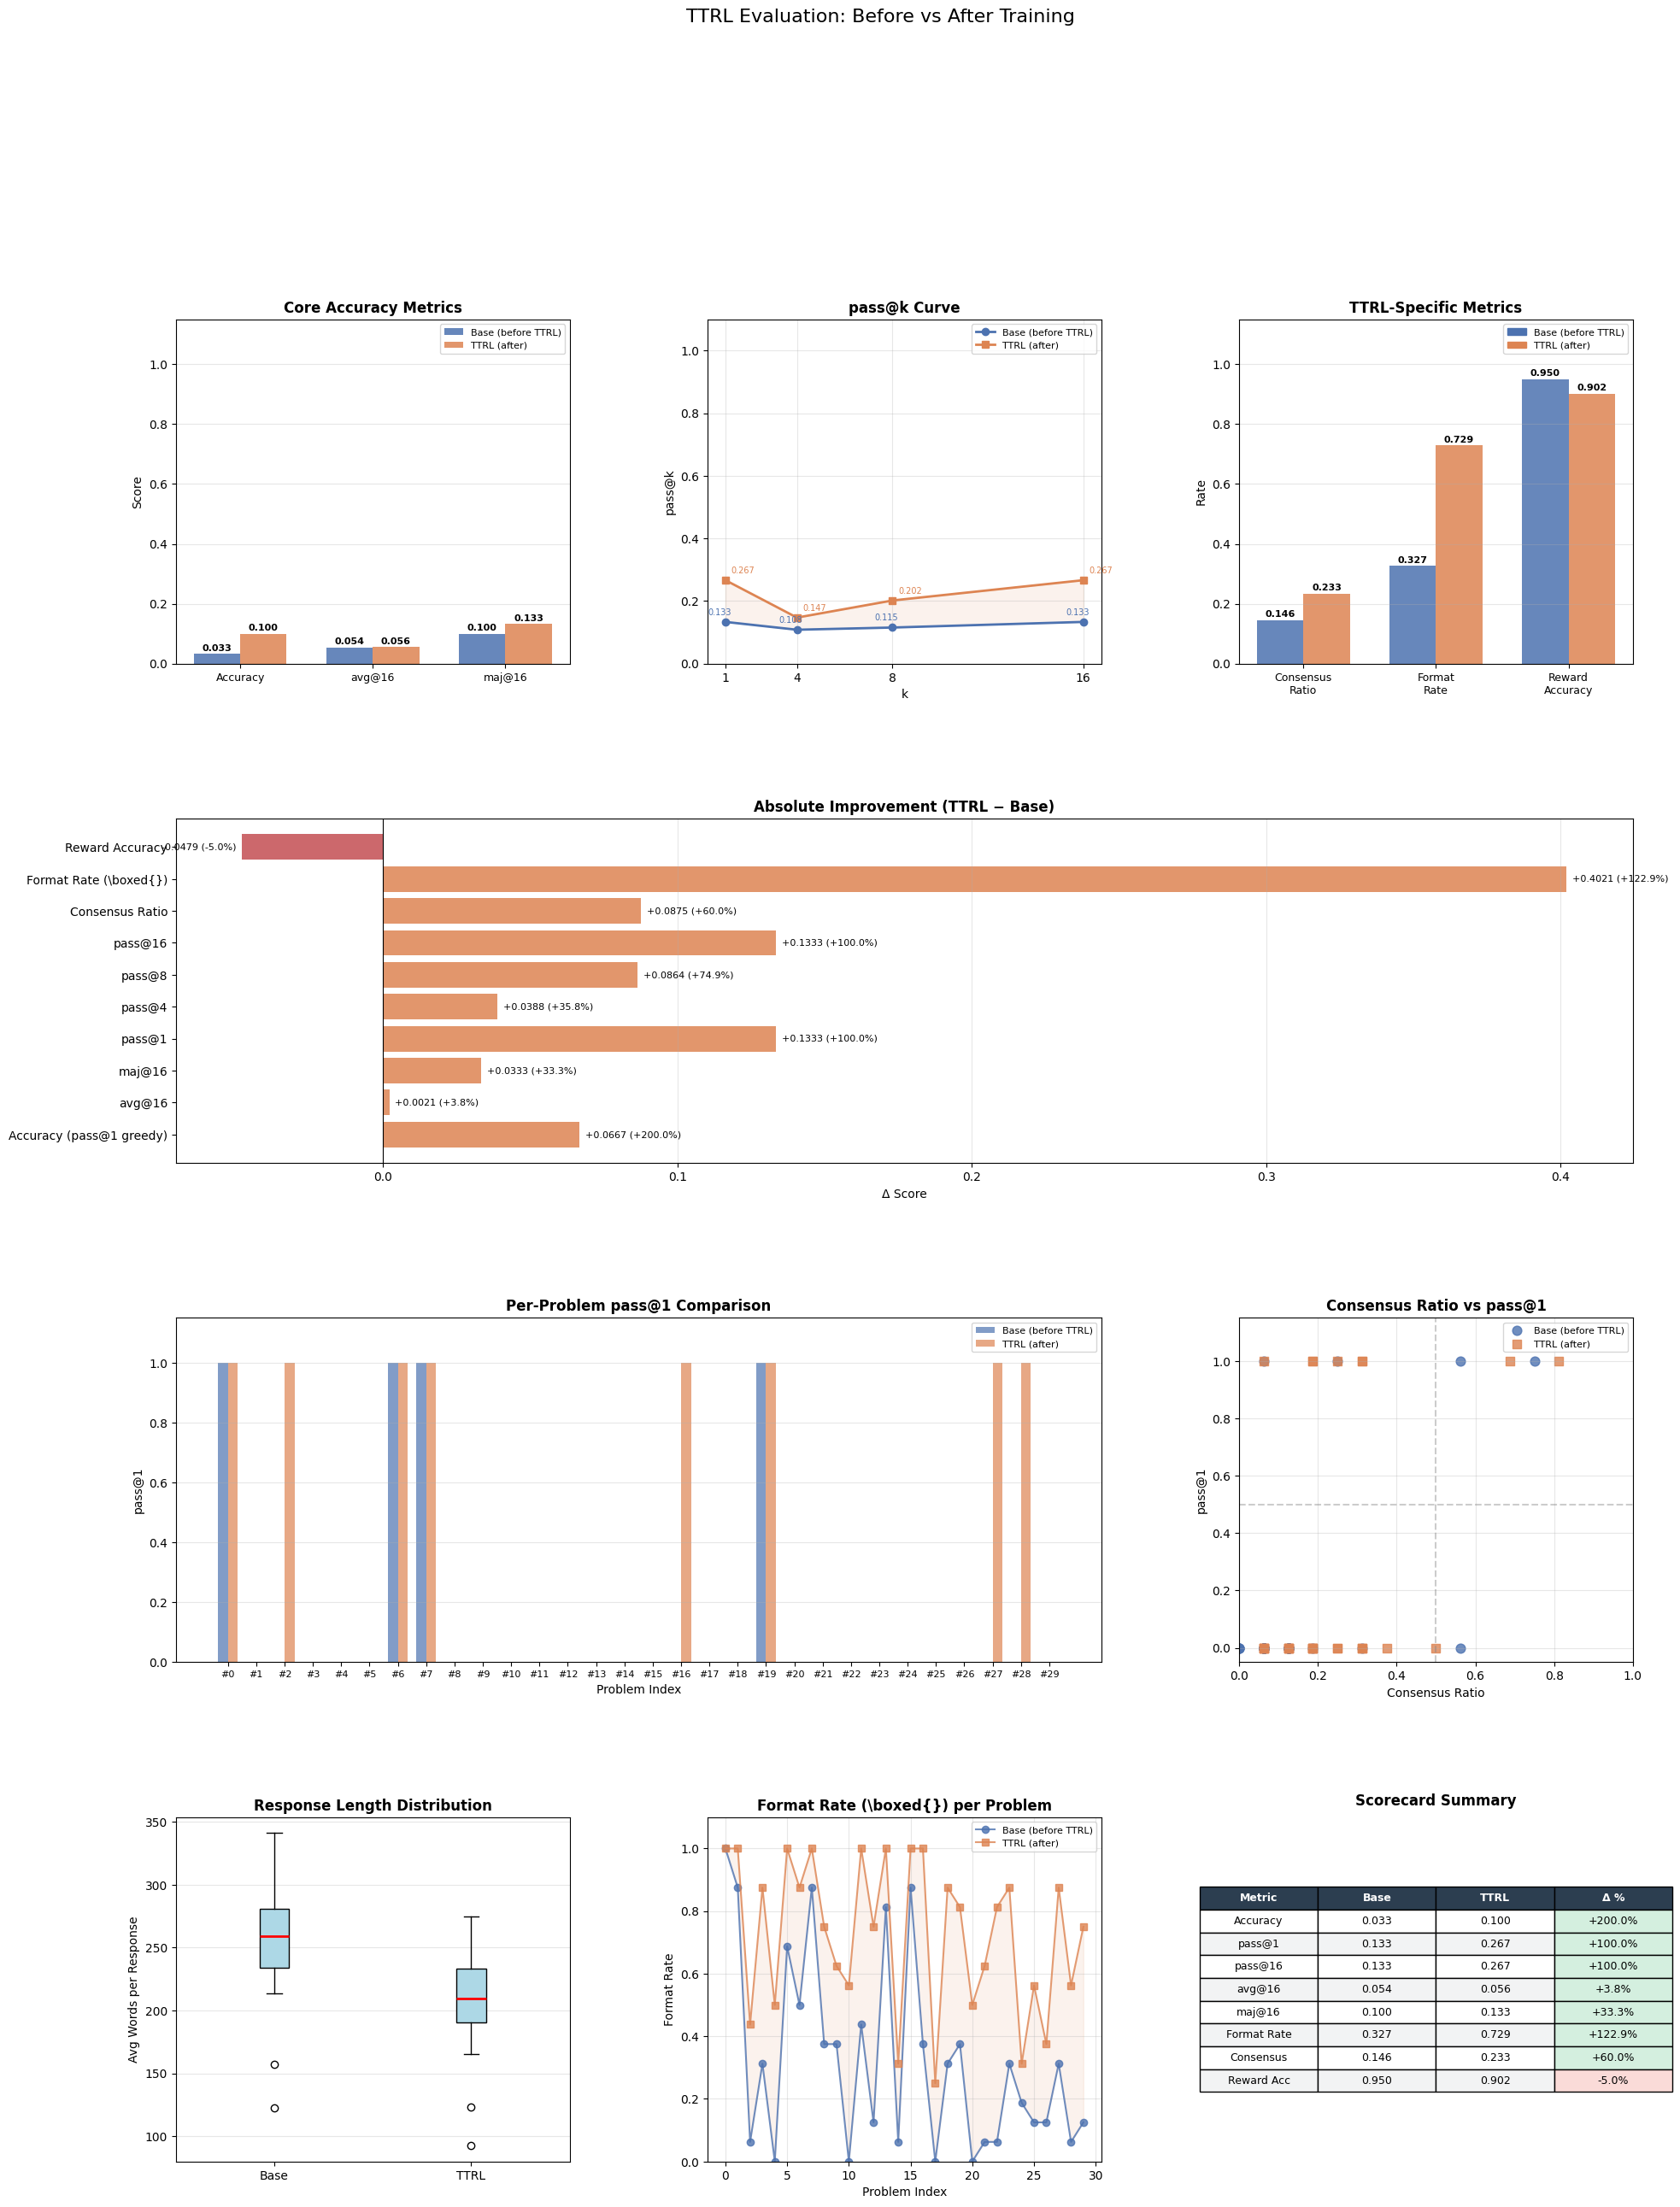


✅ Evaluation complete. Plot saved → ttrl_evaluation_MATH_l5_Qwen2.5-Math-0.5B-Instruct/ttrl_evaluation.png


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. VISUALIZATIONS
# ─────────────────────────────────────────────────────────────────────────────

BASE_COLOR = "#4C72B0"
TTRL_COLOR = "#DD8452"
COLORS     = [BASE_COLOR, TTRL_COLOR]
LABELS     = ["Base (before TTRL)", "TTRL (after)"]

def add_value_labels(ax, bars, fmt=".3f"):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.005,
            f"{h:{fmt}}",
            ha="center", va="bottom", fontsize=8, fontweight="bold"
        )

fig = plt.figure(figsize=(22, 28))
fig.suptitle("TTRL Evaluation: Before vs After Training", fontsize=16, y=1.01)
gs  = fig.add_gridspec(4, 3, hspace=0.45, wspace=0.35)

# ── Plot 1: Core accuracy metrics ────────────────────────────────────────────
ax1   = fig.add_subplot(gs[0, 0])
mkeys = ["accuracy", "avg@n", "maj@n"]
x     = np.arange(len(mkeys))
w     = 0.35
bars_b = ax1.bar(x - w/2,
                 [base_summary_5[k] for k in mkeys],
                 w, color=BASE_COLOR, label=LABELS[0], alpha=0.85)
bars_t = ax1.bar(x + w/2,
                 [ttrl_summary_5[k] for k in mkeys],
                 w, color=TTRL_COLOR, label=LABELS[1], alpha=0.85)
add_value_labels(ax1, bars_b)
add_value_labels(ax1, bars_t)
ax1.set_xticks(x)
ax1.set_xticklabels(["Accuracy", f"avg@{N_SAMPLES}", f"maj@{N_SAMPLES}"],
                    fontsize=9)
ax1.set_title("Core Accuracy Metrics", fontweight="bold")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.15)
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

# ── Plot 2: pass@k curve ──────────────────────────────────────────────────────
ax2    = fig.add_subplot(gs[0, 1])
ks     = K_VALUES
base_pk = [base_summary_5[f"pass@{k}"] for k in ks]
ttrl_pk = [ttrl_summary_5[f"pass@{k}"] for k in ks]
ax2.plot(ks, base_pk, "o-", color=BASE_COLOR, label=LABELS[0], linewidth=2)
ax2.plot(ks, ttrl_pk, "s-", color=TTRL_COLOR, label=LABELS[1], linewidth=2)
for k, b, t in zip(ks, base_pk, ttrl_pk):
    ax2.annotate(f"{b:.3f}", (k, b), textcoords="offset points",
                 xytext=(-15, 6), fontsize=7, color=BASE_COLOR)
    ax2.annotate(f"{t:.3f}", (k, t), textcoords="offset points",
                 xytext=(5, 6),  fontsize=7, color=TTRL_COLOR)
ax2.fill_between(ks, base_pk, ttrl_pk, alpha=0.1, color=TTRL_COLOR)
ax2.set_xlabel("k"); ax2.set_ylabel("pass@k")
ax2.set_title("pass@k Curve", fontweight="bold")
ax2.set_xticks(ks)
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# ── Plot 3: TTRL-specific metrics ─────────────────────────────────────────────
ax3   = fig.add_subplot(gs[0, 2])
tkeys = ["consensus_ratio", "format_rate", "reward_accuracy"]
tlabs = ["Consensus\nRatio", "Format\nRate", "Reward\nAccuracy"]
x     = np.arange(len(tkeys))
bars_b = ax3.bar(x - w/2,
                 [base_summary_5[k] for k in tkeys],
                 w, color=BASE_COLOR, alpha=0.85)
bars_t = ax3.bar(x + w/2,
                 [ttrl_summary_5[k] for k in tkeys],
                 w, color=TTRL_COLOR, alpha=0.85)
add_value_labels(ax3, bars_b)
add_value_labels(ax3, bars_t)
ax3.set_xticks(x); ax3.set_xticklabels(tlabs, fontsize=9)
ax3.set_title("TTRL-Specific Metrics", fontweight="bold")
ax3.set_ylabel("Rate")
ax3.set_ylim(0, 1.15)
ax3.grid(axis="y", alpha=0.3)
ax3.legend(handles=[
    mpatches.Patch(color=BASE_COLOR, label=LABELS[0]),
    mpatches.Patch(color=TTRL_COLOR, label=LABELS[1]),
], fontsize=8)

# ── Plot 4: Absolute improvement bar chart ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
plot_rows = comp_df[comp_df["key"] != "avg_resp_length"].copy()
colors_bar = [TTRL_COLOR if v >= 0 else "#C44E52"
              for v in plot_rows["abs_delta"]]
bars = ax4.barh(plot_rows["metric"], plot_rows["abs_delta"],
                color=colors_bar, alpha=0.85)
ax4.axvline(0, color="black", linewidth=0.8)
for bar, (_, row) in zip(bars, plot_rows.iterrows()):
    x_pos = bar.get_width()
    label = f"{x_pos:+.4f} ({row['pct_delta']:+.1f}%)"
    ax4.text(
        x_pos + (0.002 if x_pos >= 0 else -0.002),
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        ha="left" if x_pos >= 0 else "right",
        fontsize=8,
    )
ax4.set_title("Absolute Improvement (TTRL − Base)", fontweight="bold")
ax4.set_xlabel("Δ Score")
ax4.grid(axis="x", alpha=0.3)

# ── Plot 5: Per-problem pass@1 comparison ─────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
x   = np.arange(len(test_dataset_1))
ax5.bar(x - w/2, base_df_5["pass@1"], w, color=BASE_COLOR,
        alpha=0.7, label=LABELS[0])
ax5.bar(x + w/2, ttrl_df_5["pass@1"], w, color=TTRL_COLOR,
        alpha=0.7, label=LABELS[1])
ax5.set_xlabel("Problem Index")
ax5.set_ylabel("pass@1")
ax5.set_title("Per-Problem pass@1 Comparison", fontweight="bold")
ax5.set_xticks(x)
ax5.set_xticklabels(
    [f"#{i}" for i in range(len(test_dataset_1))], fontsize=8
)
ax5.set_ylim(0, 1.15)
ax5.legend(fontsize=8)
ax5.grid(axis="y", alpha=0.3)

# ── Plot 6: Consensus ratio per problem ───────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.scatter(base_df_5["consensus_ratio"], base_df_5["pass@1"],
            color=BASE_COLOR, alpha=0.8, label=LABELS[0], s=60)
ax6.scatter(ttrl_df_5["consensus_ratio"], ttrl_df_5["pass@1"],
            color=TTRL_COLOR, alpha=0.8, label=LABELS[1], s=60, marker="s")
ax6.set_xlabel("Consensus Ratio")
ax6.set_ylabel("pass@1")
ax6.set_title("Consensus Ratio vs pass@1", fontweight="bold")
ax6.set_xlim(0, 1); ax6.set_ylim(-0.05, 1.15)
ax6.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
ax6.axvline(0.5, color="gray", linestyle="--", alpha=0.4)
ax6.legend(fontsize=8)
ax6.grid(alpha=0.3)

# ── Plot 7: Response length comparison ───────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0])
ax7.boxplot(
    [base_df_5["avg_resp_length"], ttrl_df_5["avg_resp_length"]],
    labels=["Base", "TTRL"],
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
    medianprops=dict(color="red", linewidth=2),
)
ax7.set_title("Response Length Distribution", fontweight="bold")
ax7.set_ylabel("Avg Words per Response")
ax7.grid(axis="y", alpha=0.3)

# ── Plot 8: Format rate per problem ──────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 1])
ax8.plot(range(len(test_dataset_1)), base_df_5["format_rate"],
         "o-", color=BASE_COLOR, label=LABELS[0], alpha=0.8)
ax8.plot(range(len(test_dataset_1)), ttrl_df_5["format_rate"],
         "s-", color=TTRL_COLOR, label=LABELS[1], alpha=0.8)
ax8.fill_between(range(len(test_dataset_1)),
                 base_df_5["format_rate"], ttrl_df_5["format_rate"],
                 alpha=0.1, color=TTRL_COLOR)
ax8.set_xlabel("Problem Index")
ax8.set_ylabel("Format Rate")
ax8.set_title(r"Format Rate (\boxed{}) per Problem", fontweight="bold")
ax8.set_ylim(0, 1.1)
ax8.legend(fontsize=8)
ax8.grid(alpha=0.3)

# ── Plot 9: Summary scorecard ─────────────────────────────────────────────────
ax9 = fig.add_subplot(gs[3, 2])
ax9.axis("off")
scorecard_metrics = [
    ("accuracy",        "Accuracy"),
    (f"pass@1",         "pass@1"),
    (f"pass@{N_SAMPLES}", f"pass@{N_SAMPLES}"),
    ("avg@n",           f"avg@{N_SAMPLES}"),
    ("maj@n",           f"maj@{N_SAMPLES}"),
    ("format_rate",     "Format Rate"),
    ("consensus_ratio", "Consensus"),
    ("reward_accuracy", "Reward Acc"),
]
table_data = []
for key, lbl in scorecard_metrics:
    b   = base_summary_5.get(key, 0)
    t   = ttrl_summary_5.get(key, 0)
    pct = (t - b) / b * 100 if b != 0 else float("inf")
    table_data.append([lbl, f"{b:.3f}", f"{t:.3f}", f"{pct:+.1f}%"])

table = ax9.table(
    cellText=table_data,
    colLabels=["Metric", "Base", "TTRL", "Δ %"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.6)

# Colour header and improvement cells
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    elif c == 3 and r > 0:
        val = table_data[r-1][3]
        num = float(val.replace("%","").replace("+",""))
        cell.set_facecolor("#d4efdf" if num > 0 else "#fadbd8")
    elif r % 2 == 0:
        cell.set_facecolor("#f2f3f4")

ax9.set_title("Scorecard Summary", fontweight="bold", pad=10)

plt.savefig(f"{OUTPUT_DIR_5}/ttrl_evaluation.png", dpi=150,
            bbox_inches="tight")
plt.show()
print(f"\n✅ Evaluation complete. Plot saved → {OUTPUT_DIR_5}/ttrl_evaluation.png")